# Credit Card Fraud Detection - SageMaker Pipeline

This notebook implements an end-to-end Machine Learning pipeline to train, evaluate, and package a Credit Card Fraud Detection model using XGBoost, and register/deploy it using AWS SageMaker.

### Pipeline Workflow:
1. **Environment Setup & Dependency Installation**
2. **Data Loading & Exploratory Data Analysis (EDA)**
3. **Data Preprocessing & Categorical Encoding**
4. **XGBoost Classifier Training & Evaluation**
5. **Model Serialization & Export to S3**
6. **Model Registration and Deployment in SageMaker Model Registry**

In [1]:
pip install pandas scikit-learn boto3

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas
import sklearn
import boto3

In [3]:
!pip install xgboost -q

In [4]:
!pip install matplotlib seaborn

## 1. Import Libraries

We import the required libraries for data manipulation (`pandas`, `numpy`), preprocessing (`LabelEncoder`, `train_test_split`), model evaluation metrics, model implementation (`XGBClassifier`), plotting (`matplotlib`, `seaborn`), and AWS services (`boto3`, `sagemaker`).

In [5]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_auc_score 
from xgboost import XGBClassifier 
import matplotlib.pyplot as plt 
import seaborn as sns 

## 2. Data Loading & Exploratory Data Analysis (EDA)

Load the dataset `fraud.csv`, check its shape, print column datatypes, count missing values, and plot the class balance of the target label `is_fraud`.

In [6]:
df=pd.read_csv("fraud.csv") 
df.head() 

,transaction_id,amount,transaction_type,merchant_category,customer_age,customer_tenure_months,transactions_last_24h,device_type,location_match,international_transaction,is_fraud
0,T100000,56.31,Card,Electronics,25,42,17,iOS,1,0,0
1,T100001,361.21,Card,Food,60,38,14,Web,1,0,0
2,T100002,158.01,UPI,Utility,29,82,19,iOS,1,0,0
3,T100003,109.55,NEFT,Retail,18,45,22,iOS,0,0,0
4,T100004,20.35,Card,Utility,74,35,24,Android,1,0,0


In [7]:
print(df.shape) 
df.info() 
df.describe() 
df.isnull().sum() 

(500, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             500 non-null    object 
 1   amount                     500 non-null    float64
 2   transaction_type           500 non-null    object 
 3   merchant_category          500 non-null    object 
 4   customer_age               500 non-null    int64  
 5   customer_tenure_months     500 non-null    int64  
 6   transactions_last_24h      500 non-null    int64  
 7   device_type                500 non-null    object 
 8   location_match             500 non-null    int64  
 9   international_transaction  500 non-null    int64  
 10  is_fraud                   500 non-null    int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 43.1+ KB


transaction_id               0
amount                       0
transaction_type             0
merchant_category            0
customer_age                 0
customer_tenure_months       0
transactions_last_24h        0
device_type                  0
location_match               0
international_transaction    0
is_fraud                     0
dtype: int64

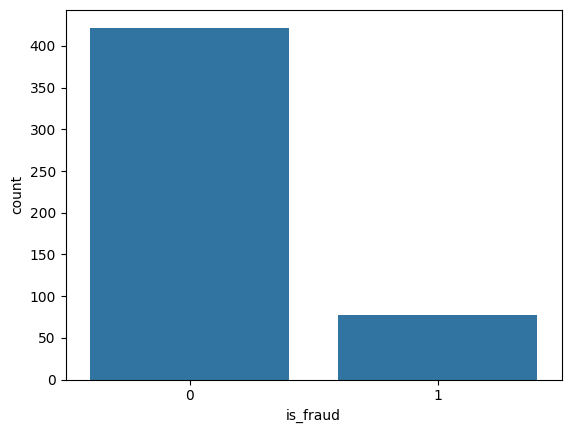

In [8]:
df["is_fraud"].value_counts() 
sns.countplot(data=df,x="is_fraud") 
plt.show() 

## 3. Data Preprocessing & Categorical Encoding

1. Categorical columns (`transaction_type`, `merchant_category`, `device_type`) are encoded as integers using `LabelEncoder`.
2. Identifiers (`transaction_id`) and the target label (`is_fraud`) are separated from training features.
3. The dataset is split into training (80%) and testing (20%) sets. Since fraud datasets are heavily imbalanced, **stratification** is enabled to ensure both splits maintain identical target ratios.

In [9]:
categorical_columns=["transaction_type","merchant_category","device_type"] 
encoder=LabelEncoder() 
for c in categorical_columns: 
    df[c]=encoder.fit_transform(df[c]) 

In [10]:
X=df.drop(["transaction_id","is_fraud"],axis=1) 
y=df["is_fraud"] 

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## 4. XGBoost Classifier Training & Evaluation

Train an `XGBClassifier` with custom hyperparameters (`n_estimators=200`, `max_depth=6`). We evaluate the model using accuracy, precision, recall, f1-score, and ROC-AUC. We also plot a confusion matrix heatmap and analyze feature importances.

In [12]:
model=XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,random_state=42) 
model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [13]:
pred=model.predict(X_test) 
prob=model.predict_proba(X_test)[:,1] 

In [14]:
print(accuracy_score(y_test,pred)) 
print(precision_score(y_test,pred)) 
print(recall_score(y_test,pred)) 
print(f1_score(y_test,pred)) 
print(roc_auc_score(y_test,prob)) 

0.78
0.25
0.1875
0.21428571428571427
0.6569940476190476


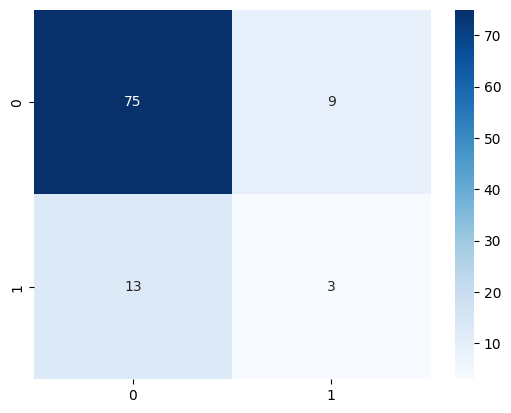

In [15]:
cm=confusion_matrix(y_test,pred) 
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues') 
plt.show() 

In [16]:
importance=model.feature_importances_ 
feature_importance=pd.DataFrame({"Feature":X.columns,"Importance":importance}) 

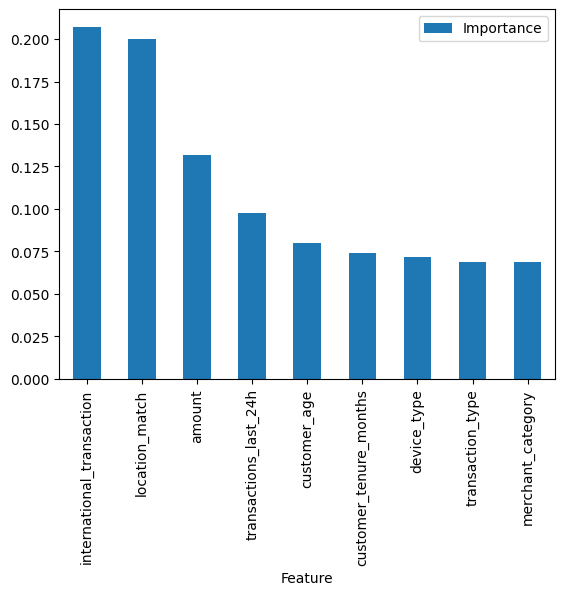

In [17]:
feature_importance.sort_values(by="Importance",ascending=False).plot(kind="bar",x="Feature",y="Importance") 
plt.show() 

## 5. Model Serialization & Export

We serialize the trained model using `joblib`, verify the local predictions with a dummy data point, package the model, and upload it to Amazon S3.

In [18]:
import joblib 
joblib.dump(model,"fraud_detection_model.pkl") 

['fraud_detection_model.pkl']

In [19]:
sample=pd.DataFrame({"amount":[650],"transaction_type":[2],"merchant_category":[3],"customer_age":[42],"customer_tenure_months":[25],"transactions_last_24h":[18],"device_type":[0],"location_match":[0],"international_transaction":[1]}) 
print(model.predict(sample)) 
print(model.predict_proba(sample)) 

[1]
[[0.02592671 0.9740733 ]]


In [20]:
import boto3 
s3=boto3.client("s3") 
bucket="ml-engineering-lab-2026" 
s3.upload_file("fraud_detection_model.pkl",bucket,"models/fraud_detection_model.pkl") 

In [21]:
import tarfile 
 
with tarfile.open("fraud_detection_model.tar.gz", "w:gz") as tar: 
    tar.add("fraud_detection_model.pkl") 
 
print("Model compressed successfully.") 

Model compressed successfully.


## 6. AWS SageMaker Deployment & Model Registry

Using the SageMaker Python SDK, we register the model in the SageMaker Model Registry under the group `FraudDetectionModelGroup`. We specify `inference.py` as our entry point for loading the model and parsing CSV requests at runtime.

In [22]:
response = s3.list_objects_v2( 
    Bucket=bucket, 
    Prefix="models/" 
) 
 
for obj in response["Contents"]: 
    print(obj["Key"]) 

models/fraud_detection_model.pkl
models/fraud_detection_model.tar.gz


In [23]:
import sagemaker 
from sagemaker import get_execution_role 
 
session = sagemaker.Session() 
role = get_execution_role() 

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


In [24]:
from sagemaker.sklearn.model import SKLearnModel 
 
model = SKLearnModel( 
    model_data=f"s3://{bucket}/models/fraud_detection_model.tar.gz", 
    role=role, 
    entry_point="inference.py", 
    framework_version="1.2-1", 
    py_version="py3" 
) 

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/model.py:347: SageMakerV2DeprecationWarning: SKLearnModel is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
SKLearnModel is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


In [25]:
sm = boto3.client("sagemaker") 
 
sm.create_model_package_group( 
    ModelPackageGroupName="FraudDetectionModelGroup", 
    ModelPackageGroupDescription="Fraud Detection Models" 
) 

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:3                                                                                    │
│                                                                                                  │
│   1 sm = boto3.client("sagemaker")                                                               │
│   2                                                                                              │
│ ❱ 3 sm.create_model_package_group(                                                               │
│   4 │   ModelPackageGroupName="FraudDetectionModelGroup",                                        │
│   5 │   ModelPackageGroupDescription="Fraud Detection Models"                                    │
│   6 )                                                                                            │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/client.py:606 in     │
│ _api_call                                                                                        │
│                                                                                                  │
│    603 │   │   │   │   │   f"{py_operation_name}() only accepts keyword arguments."              │
│    604 │   │   │   │   )                                                                         │
│    605 │   │   │   # The "self" in this scope is referring to the BaseClient.                    │
│ ❱  606 │   │   │   return self._make_api_call(operation_name, kwargs)                            │
│    607 │   │                                                                                     │
│    608 │   │   _api_call.__name__ = str(py_operation_name)                                       │
│    609                                                                                           │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/context.py:123 in    │
│ wrapper                                                                                          │
│                                                                                                  │
│   120 │   │   │   with start_as_current_context():                                               │
│   121 │   │   │   │   if hook:                                                                   │
│   122 │   │   │   │   │   hook()                                                                 │
│ ❱ 123 │   │   │   │   return func(*args, **kwargs)                                               │
│   124 │   │                                                                                      │
│   125 │   │   return wrapper                                                                     │
│   126                                                                                            │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/client.py:1094 in    │
│ _make_api_call                                                                                   │
│                                                                                                  │
│   1091 │   │   │   │   'error_code_override'                                                     │
│   1092 │   │   │   ) or error_info.get("Code")                                                   │
│   1093 │   │   │   error_class = self.exceptions.from_code(error_code)                           │
│ ❱ 1094 │   │   │   raise error_class(parsed_response, operation_name)                            │
│   1095 │   │   else:                                       

In [26]:
import boto3

s3 = boto3.client("s3")

response = s3.list_objects_v2(
    Bucket="ml-engineering-lab-2026",
    Prefix="models/"
)

for obj in response.get("Contents", []):
    print(obj["Key"])

models/fraud_detection_model.pkl
models/fraud_detection_model.tar.gz


In [27]:
print(model.model_data)

s3://ml-engineering-lab-2026/models/fraud_detection_model.tar.gz


In [28]:
import tarfile

with tarfile.open("fraud_detection_model.tar.gz", "w:gz") as tar:
    tar.add("fraud_detection_model.pkl")

In [29]:
import boto3

s3 = boto3.client("s3")

s3.upload_file(
    "fraud_detection_model.tar.gz",
    "ml-engineering-lab-2026",
    "models/fraud_detection_model.tar.gz"
)

In [30]:
print(model.model_data)

s3://ml-engineering-lab-2026/models/fraud_detection_model.tar.gz


In [31]:
model_package = model.register( 
    content_types=["text/csv"], 
    response_types=["text/csv"], 
    inference_instances=["ml.m5.large"], 
    transform_instances=["ml.m5.large"], 
    model_package_group_name="FraudDetectionModelGroup", 
    approval_status="PendingManualApproval", 
    description="Fraud Detection Model Version 1" 
) 

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/model.py:347: SageMakerV2DeprecationWarning: ModelPackage is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
ModelPackage is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


In [32]:
print(model_package)
print(type(model_package))

<class 'sagemaker.model.ModelPackage'>


In [33]:
print(model_package.model_package_arn)

arn:aws:sagemaker:ap-south-1:066653777072:model-package/FraudDetectionModelGroup/3


In [34]:
#Chexking it
import boto3

sm = boto3.client("sagemaker")

response = sm.describe_model_package(
    ModelPackageName=model_package.model_package_arn
)

print(response["ModelPackageStatus"])

Completed


In [35]:
import sagemaker
print(sagemaker.__version__)

2.257.5


In [36]:
print(model_package.model_package_arn)

arn:aws:sagemaker:ap-south-1:066653777072:model-package/FraudDetectionModelGroup/3


In [37]:
response = sm.list_model_packages(
    ModelPackageGroupName="FraudDetectionModelGroup"
)

response["ModelPackageSummaryList"]

[{'ModelPackageGroupName': 'FraudDetectionModelGroup',
  'ModelPackageVersion': 3,
  'ModelPackageArn': 'arn:aws:sagemaker:ap-south-1:066653777072:model-package/FraudDetectionModelGroup/3',
  'ModelPackageDescription': 'Fraud Detection Model Version 1',
  'CreationTime': datetime.datetime(2026, 7, 29, 12, 22, 20, 904000, tzinfo=tzlocal()),
  'ModelPackageStatus': 'Completed',
  'ModelApprovalStatus': 'PendingManualApproval',
  'ModelPackageRegistrationType': 'Registered'},
 {'ModelPackageGroupName': 'FraudDetectionModelGroup',
  'ModelPackageVersion': 2,
  'ModelPackageArn': 'arn:aws:sagemaker:ap-south-1:066653777072:model-package/FraudDetectionModelGroup/2',
  'ModelPackageDescription': 'Fraud Detection Model Version 1',
  'CreationTime': datetime.datetime(2026, 7, 29, 12, 5, 21, 448000, tzinfo=tzlocal()),
  'ModelPackageStatus': 'Completed',
  'ModelApprovalStatus': 'Approved',
  'ModelPackageRegistrationType': 'Registered'},
 {'ModelPackageGroupName': 'FraudDetectionModelGroup',
  '

In [38]:
arn = response["ModelPackageSummaryList"][0]["ModelPackageArn"] 
 
sm.update_model_package( 
    ModelPackageArn=arn, 
    ModelApprovalStatus="Approved" 
) 
 
print("Model Approved Successfully") 

Model Approved Successfully


In [39]:
details = sm.describe_model_package( 
    ModelPackageName=arn 
) 
 
print(details["ModelApprovalStatus"]) 

Approved


In [40]:
import sagemaker
print(sagemaker.get_execution_role())

arn:aws:iam::066653777072:role/service-role/SageMaker-ExecutionRole-20260129T171804


In [41]:
import boto3

sm = boto3.client("sagemaker")

sm.create_endpoint_config(
    EndpointConfigName="test-endpoint-config"
)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:5                                                                                    │
│                                                                                                  │
│   2                                                                                              │
│   3 sm = boto3.client("sagemaker")                                                               │
│   4                                                                                              │
│ ❱ 5 sm.create_endpoint_config(                                                                   │
│   6 │   EndpointConfigName="test-endpoint-config"                                                │
│   7 )                                                                                            │
│   8                                                                                              │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/client.py:606 in     │
│ _api_call                                                                                        │
│                                                                                                  │
│    603 │   │   │   │   │   f"{py_operation_name}() only accepts keyword arguments."              │
│    604 │   │   │   │   )                                                                         │
│    605 │   │   │   # The "self" in this scope is referring to the BaseClient.                    │
│ ❱  606 │   │   │   return self._make_api_call(operation_name, kwargs)                            │
│    607 │   │                                                                                     │
│    608 │   │   _api_call.__name__ = str(py_operation_name)                                       │
│    609                                                                                           │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/context.py:123 in    │
│ wrapper                                                                                          │
│                                                                                                  │
│   120 │   │   │   with start_as_current_context():                                               │
│   121 │   │   │   │   if hook:                                                                   │
│   122 │   │   │   │   │   hook()                                                                 │
│ ❱ 123 │   │   │   │   return func(*args, **kwargs)                                               │
│   124 │   │                                                                                      │
│   125 │   │   return wrapper                                                                     │
│   126                                                                                            │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/client.py:1051 in    │
│ _make_api_call                                                                                   │
│                                                                                                  │
│   1048 │   │   │   # Pass arbitrary endpoint info with the Request                               │
│   1049 │   │   │   # for use during construction.                                                │
│   1050 │   │   │   request_context['endpoint_properties'] = properties                           │
│ ❱ 1051 │   │   request_dict = self._convert_to_request_dict

In [ ]:
#DEploying the Endpoint now
predictor = model.deploy( 
    initial_instance_count=1, 
    instance_type="ml.m5.large" 
) 

---

In [ ]:
response=s3.list_objects_v2(Bucket=bucket,Prefix="models/") 
response["Contents"] 

In [ ]:
import boto3 
import sagemaker 
from sagemaker.model import Model 
from sagemaker import get_execution_role 
 
session = sagemaker.Session() 
role = get_execution_role() 
sm_client = boto3.client("sagemaker") 

In [ ]:
model_artifact = "s3://ml-engineering-lab-2026/models/fraud_detection_model.pkl" 

In [ ]:
from sagemaker.sklearn.model import SKLearnModel 
 
model = SKLearnModel( 
    model_data=model_artifact, 
    role=role, 
    entry_point="inference.py", 
    framework_version="1.2-1", 
    py_version="py3" 
)

In [ ]:
sm_client.create_model_package_group( 
    ModelPackageGroupName="FraudDetectionModelGroup", 
    ModelPackageGroupDescription="Fraud Detection Models" 
) 

In [ ]:
model_package = model.register( 
    content_types=["text/csv"], 
    response_types=["text/csv"], 
    inference_instances=["ml.m5.large"], 
    transform_instances=["ml.m5.large"], 
    model_package_group_name="FraudDetectionModelGroup", 
    approval_status="PendingManualApproval", 
    description="Fraud Detection Model Version 1" 
) 

In [ ]:
model_package.wait_for_model_package() 